In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mesa_reader as mr

import sys
sys.path.append('..')
from src.util import MESA_DATA_DIR, DATA_DIR

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


In [118]:
plt.style.use('plotstyle.mplstyle')

In [2]:
def get_model_folder(model_id, verbose=True):
    """Finds model folder given its id."""
    matches = list(PROJECT_FOLDER.glob(f'{model_id}*'))
    
    if len(matches) > 1:
        if verbose:
            print('\n'.join((
                f'Multiple matches for id {model_id} found in {PROJECT_FOLDER}:',
                *[str(match) for match in matches]
            )))
        return
    elif len(matches) != 0:
        match = matches[0]
        if verbose:
            print(f'Found match {match}')
        return match
    else:
        if verbose:
            print(f'No matches found in {PROJECT_FOLDER}')
        return           
    
def get_model_dict(grid_folder):
    """Given a model folder, loads the paths of specific stars into a 
    m1, p_orb dictionary."""
    d = dict()
    for model_folder in grid_folder.glob('m*_p*_w*'):
        if model_folder.suffix == '.log':
            continue
        m, p, w = model_folder.name.replace('d', 'e').split('_')
        w = float(w.lstrip('w'))
        p = f'{float(p.lstrip("p")):.2f}'      
        m = f'{float(m.lstrip("m")):.1f}'
        
        if m not in d.keys():
            d[m] = dict()
        d[m][p] = model_folder
    return d

In [3]:
PROJECT_BASE = MESA_DATA_DIR / '00_fiducial'

# Each entry: { label used in all_model_dicts : (variable suffix, folder name) }
metallicity_map = {
  #  '0.0005': ('0005zsun', '0000_ZdivZsun_5d-03'),
  #  '0.001':  ('001zsun',  '0001_ZdivZsun_1d-02'),
    '0.02':  ('002zsun',  '0002_ZdivZsun_2d-02'),
    '0.04':  ('004zsun',  '0003_ZdivZsun_4d-02'),
    '0.08':  ('008zsun',  '0004_ZdivZsun_8d-02'),
    '0.1':   ('01zsun',   '0005_ZdivZsun_1d-01'),
    '0.2':   ('02zsun',   '0006_ZdivZsun_2d-01'),
    '0.3':   ('03zsun',   '0007_ZdivZsun_3d-01'),
    '0.4':   ('04zsun',   '0008_ZdivZsun_4d-01'),
}

# initialize container for final dict
all_model_dicts = {}

for z_label, (suffix, folder_name) in metallicity_map.items():
    PROJECT_FOLDER = PROJECT_BASE / folder_name

    model_ids = np.arange(1, 25, 1)
    model_ids = np.array([f'{id:03d}' for id in model_ids])
    model_folders = np.array([get_model_folder(id) for id in model_ids])
    model_dicts = np.array([get_model_dict(folder) for folder in model_folders])
    model_labels = np.array([f'${float(id):0f}\\,\\mathrm{{M}}_\\odot$' for id in model_ids])

    # create a variable named model_dicts_XXXzsun dynamically
    globals()[f'model_dicts_{suffix}'] = model_dicts

    # add entry to final dict (same structure as before)
    all_model_dicts[z_label] = {
    k: v
    for d in model_dicts
    for k, v in d.items()
}



Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/001_m10
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/002_m15
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/003_m20
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/004_m25
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/005_m30
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/006_m35
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/007_m40
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/008_m45
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/009_m50
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/

In [4]:
import pandas as pd
core_props_df = pd.read_hdf(DATA_DIR/'00_fiducial_core_props_df.h5')

In [5]:
suc_che_df = core_props_df[(~core_props_df.is_l2of_at_zams) & (core_props_df.is_che) & (~core_props_df.is_crash)]

In [6]:
suc_che_df['z'] = suc_che_df['z_key'].astype(float)

/tmp/ipykernel_539289/2058798488.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  suc_che_df['z'] = suc_che_df['z_key'].astype(float)


In [20]:
list(suc_che_df.columns)

['z_key',
 'm_zams',
 'm_wr0',
 'm_wr1',
 'm_tams',
 'm_tahems',
 'm_cdepl',
 'm_odepl',
 'm_f',
 'm_c_zams',
 'm_c_wr0',
 'm_c_wr1',
 'm_c_tams',
 'm_c_tahems',
 'm_c_cdepl',
 'm_c_odepl',
 'm_c_f',
 'inertia_zams',
 'inertia_wr0',
 'inertia_wr1',
 'inertia_tams',
 'inertia_tahems',
 'inertia_cdepl',
 'inertia_odepl',
 'inertia_f',
 'p_spin_zams',
 'p_spin_wr0',
 'p_spin_wr1',
 'p_spin_tams',
 'p_spin_tahems',
 'p_spin_cdepl',
 'p_spin_odepl',
 'p_spin_f',
 'r_zams',
 'r_wr0',
 'r_wr1',
 'r_tams',
 'r_tahems',
 'r_cdepl',
 'r_odepl',
 'r_f',
 'r_c_zams',
 'r_c_wr0',
 'r_c_wr1',
 'r_c_tams',
 'r_c_tahems',
 'r_c_cdepl',
 'r_c_odepl',
 'r_c_f',
 'log_rho_c_zams',
 'log_rho_c_wr0',
 'log_rho_c_wr1',
 'log_rho_c_tams',
 'log_rho_c_tahems',
 'log_rho_c_cdepl',
 'log_rho_c_odepl',
 'log_rho_c_f',
 'log_j_zams',
 'log_j_wr0',
 'log_j_wr1',
 'log_j_tams',
 'log_j_tahems',
 'log_j_cdepl',
 'log_j_odepl',
 'log_j_f',
 'p_orb_zams',
 'p_orb_wr0',
 'p_orb_wr1',
 'p_orb_tams',
 'p_orb_tahems',
 'p

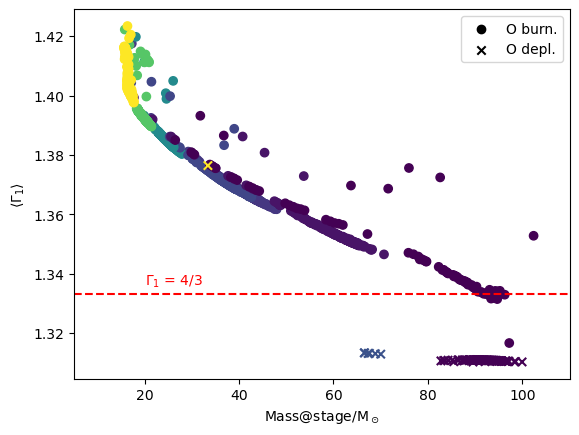

In [32]:
fig, ax = plt.subplots()

df = suc_che_df[~suc_che_df.is_O_depleted]
ax.scatter(
    df.m_f,
    df.gamma1_w_avg_f,
    marker='o',
    c=df.z
)

df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_odepl,
    df.gamma1_w_avg_odepl,
    marker='x',
    c=df.z
)



ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')

handles = [
    ax.scatter([], [], marker='o', color='k', label='O burn.'),
    ax.scatter([], [], marker='x', color='k', label='O depl.')
]
ax.legend(handles=handles, loc='upper right')

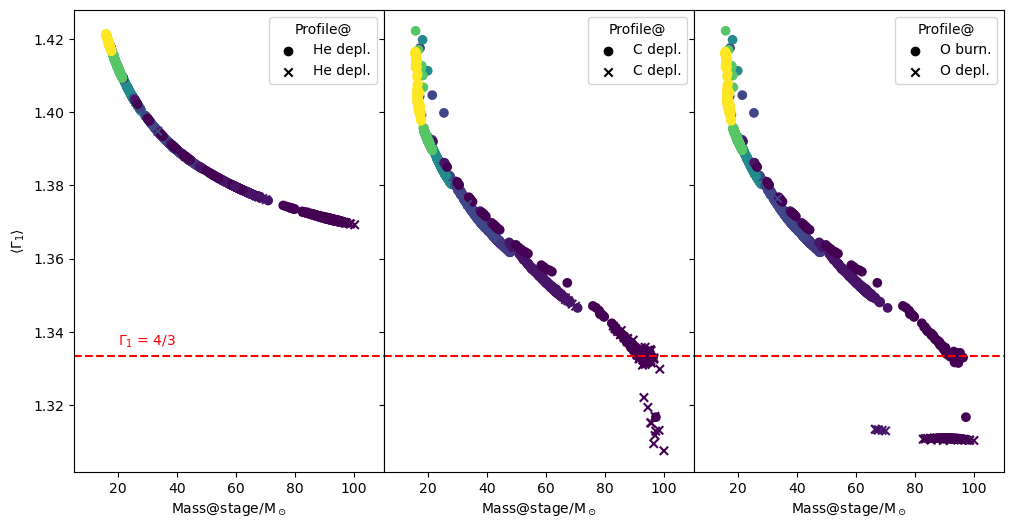

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
fig.subplots_adjust(wspace=0)


ax = axes[0]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_tahems,
    df.gamma1_w_avg_tahems,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)



df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_tahems,
    df.gamma1_w_avg_tahems,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')

handles = [
    ax.scatter([], [], marker='o', color='k', label='He depl.'),
    ax.scatter([], [], marker='x', color='k', label='He depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')


ax = axes[1]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_cdepl,
    df.gamma1_w_avg_cdepl,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)



df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_cdepl,
    df.gamma1_w_avg_cdepl,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')


ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')


handles = [
    ax.scatter([], [], marker='o', color='k', label='C depl.'),
    ax.scatter([], [], marker='x', color='k', label='C depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')

ax = axes[2]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_f,
    df.gamma1_w_avg_f,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_odepl,
    df.gamma1_w_avg_odepl,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
#ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')


handles = [
    ax.scatter([], [], marker='o', color='k', label='O burn.'),
    ax.scatter([], [], marker='x', color='k', label='O depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')

In [102]:
suc_che_df.columns

Index(['z_key', 'm_zams', 'm_wr0', 'm_wr1', 'm_tams', 'm_tahems', 'm_cdepl',
       'm_odepl', 'm_f', 'm_c_zams',
       ...
       'is_che', 'is_crit_at_zams', 'is_merger_at_zams', 'is_l2of_at_zams',
       'is_He_depleted', 'is_half_C_depleted', 'is_C_depleted',
       'is_O_depleted', 'is_crash', 'z'],
      dtype='object', length=108)

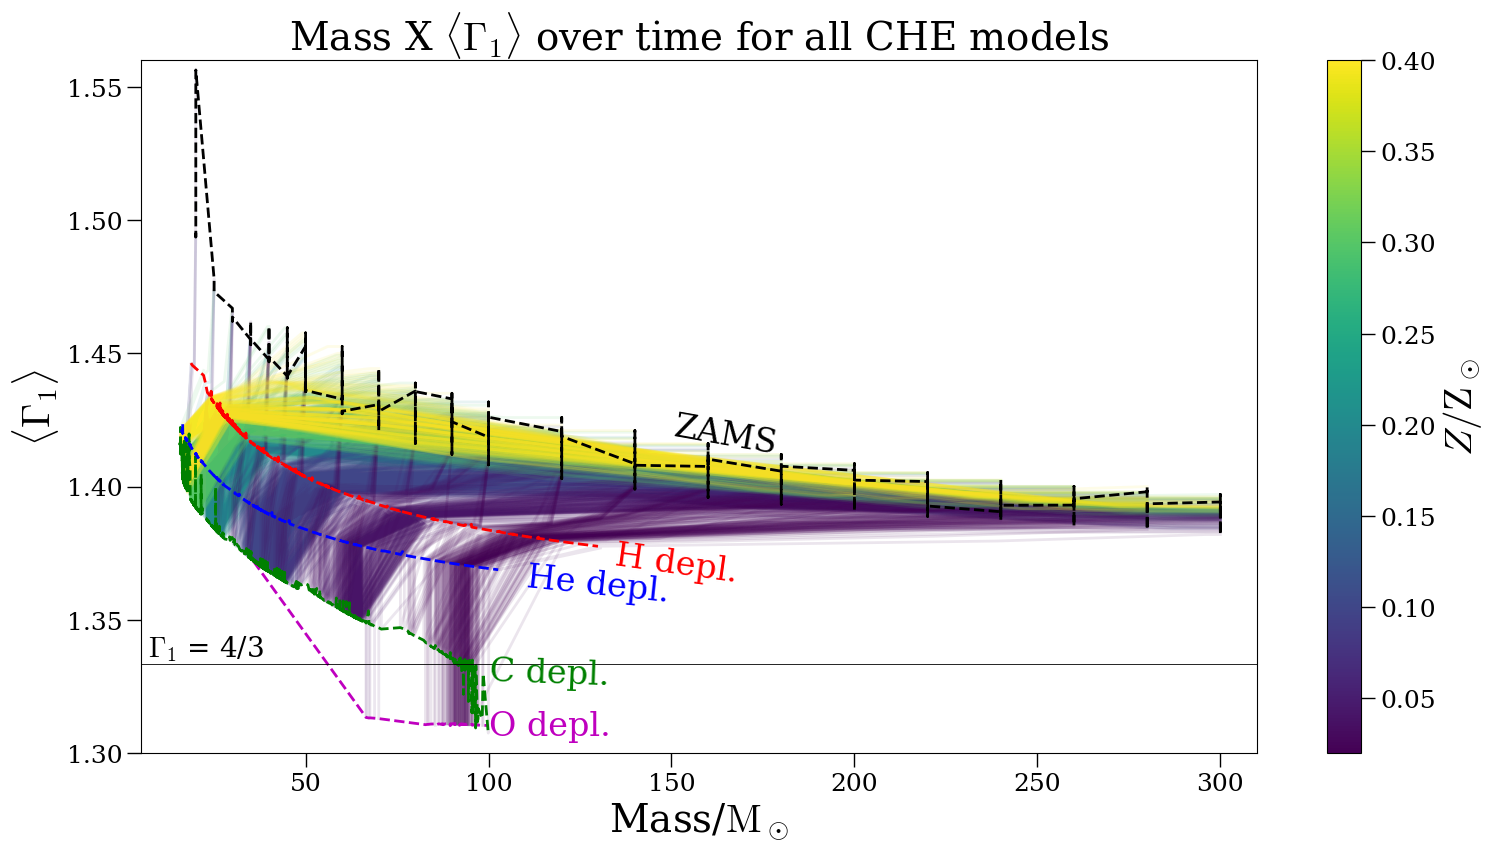

In [ ]:
stages = ['zams', 'wr0', 'wr1', 'tams', 'tahems', 'cdepl', 'odepl']

fig, ax = plt.subplots(figsize=(18, 9))

for row in suc_che_df.itertuples():
    m = [getattr(row, 'm_'+stage) for stage in stages]
    z = row.z
    gamma1_w_avg_values = [getattr(row, f'gamma1_w_avg_{stage}') for stage in stages]
    ax.plot(
        m,
        gamma1_w_avg_values,
        marker='none',
        color=plt.cm.viridis((z-0.02)/0.38),
        alpha=0.1
    )
    
all_odepl_df = suc_che_df[suc_che_df.is_O_depleted]
odepl_x = [getattr(row, 'm_odepl') for row in all_odepl_df.itertuples()]
odepl_y = [getattr(row, 'gamma1_w_avg_odepl') for row in all_odepl_df.itertuples()]
sorted_indices = np.argsort(odepl_x)
ax.plot(
    np.array(odepl_x)[sorted_indices],
    np.array(odepl_y)[sorted_indices],
    marker='none',
    color='m',
    linestyle='--',
    label='O depl.'
)

all_cdepl_df = suc_che_df[suc_che_df.is_C_depleted]
cdepl_x = [getattr(row, 'm_cdepl') for row in all_cdepl_df.itertuples()]
cdepl_y = [getattr(row, 'gamma1_w_avg_cdepl') for row in all_cdepl_df.itertuples()]
sorted_indices = np.argsort(cdepl_x)
ax.plot(
    np.array(cdepl_x)[sorted_indices],
    np.array(cdepl_y)[sorted_indices],
    marker='none',
    color='g',
    linestyle='--',
    label='C depl.'
)

all_hedepl_df = suc_che_df[suc_che_df.is_He_depleted]
hedepl_x = [getattr(row, 'm_tahems') for row in all_hedepl_df.itertuples()]
hedepl_y = [getattr(row, 'gamma1_w_avg_tahems') for row in all_hedepl_df.itertuples()]
sorted_indices = np.argsort(hedepl_x)
ax.plot(
    np.array(hedepl_x)[sorted_indices],
    np.array(hedepl_y)[sorted_indices],
    marker='none',
    color='b',
    linestyle='--',
    label='He depl.'
)

all_hdepl_df = suc_che_df[suc_che_df.is_che]
hdepl_x = [getattr(row, 'm_tams') for row in all_hdepl_df.itertuples()]
hdepl_y = [getattr(row, 'gamma1_w_avg_tams') for row in all_hdepl_df.itertuples()]
sorted_indices = np.argsort(hdepl_x)
ax.plot(
    np.array(hdepl_x)[sorted_indices],
    np.array(hdepl_y)[sorted_indices],
    marker='none',
    color='r',
    linestyle='--',
    label='H depl.'
)

all_hdepl_df = suc_che_df[suc_che_df.is_che]
hdepl_x = [getattr(row, 'm_zams') for row in all_hdepl_df.itertuples()]
hdepl_y = [getattr(row, 'gamma1_w_avg_zams') for row in all_hdepl_df.itertuples()]
sorted_indices = np.argsort(hdepl_x)
ax.plot(
    np.array(hdepl_x)[sorted_indices],
    np.array(hdepl_y)[sorted_indices],
    marker='none',
    color='k',
    linestyle='--',
    label='ZAMS'
)


###



###

ax.hlines(4/3, 5, 310, colors='k', lw=0.6, linestyles='-')
ax.text(7, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='k', fontsize=20)
ax.set_xlim(5, 310)
ax.set_ylim(1.3, 1.56)
ax.set_xlabel('Mass/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')
ax.set_title('Mass X $\\langle\Gamma_1\\rangle$ over time for all CHE models')

ax.text(150, 1.41, 'ZAMS', color='k', rotation=-10, va='bottom', ha='left', fontsize=24)
ax.text(134, 1.38, 'H depl.', color='r', rotation=-8, va='top', ha='left', fontsize=24)
ax.text(110, 1.372, 'He depl.', color='b', rotation=-6, va='top', ha='left', fontsize=24)
ax.text(100, 1.33, 'C depl.', color='g', rotation=-2, va='center', ha='left', fontsize=24)
ax.text(100, 1.31, 'O depl.', color='m', rotation=0, va='center', ha='left', fontsize=24)

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0.02, vmax=0.4)), ax=ax)
cbar.set_label('$Z/\\mathrm{Z}_\\odot$')

In [168]:
suc_che_df[(suc_che_df.is_C_depleted) & (suc_che_df.gamma1_w_avg_cdepl < 4/3) ].gamma1_center_cdepl.max()

1.3237098881485678

In [167]:
suc_che_df[(suc_che_df.is_O_depleted) & (suc_che_df.gamma1_w_avg_cdepl > 4/3) & (suc_che_df.gamma1_w_avg_odepl < 4/3)].gamma1_center_odepl.min()

1.339874861320722

In [70]:
pd.options.display.max_columns = None

In [71]:
suc_che_df[(suc_che_df.z == 0.4) & (suc_che_df.m_cdepl > 20)]

,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_cdepl,m_odepl,m_f,m_c_zams,m_c_wr0,m_c_wr1,m_c_tams,m_c_tahems,m_c_cdepl,m_c_odepl,m_c_f,inertia_zams,inertia_wr0,inertia_wr1,inertia_tams,inertia_tahems,inertia_cdepl,inertia_odepl,inertia_f,p_spin_zams,p_spin_wr0,p_spin_wr1,p_spin_tams,p_spin_tahems,p_spin_cdepl,p_spin_odepl,p_spin_f,r_zams,r_wr0,r_wr1,r_tams,r_tahems,r_cdepl,r_odepl,r_f,r_c_zams,r_c_wr0,r_c_wr1,r_c_tams,r_c_tahems,r_c_cdepl,r_c_odepl,r_c_f,log_rho_c_zams,log_rho_c_wr0,log_rho_c_wr1,log_rho_c_tams,log_rho_c_tahems,log_rho_c_cdepl,log_rho_c_odepl,log_rho_c_f,log_j_zams,log_j_wr0,log_j_wr1,log_j_tams,log_j_tahems,log_j_cdepl,log_j_odepl,log_j_f,p_orb_zams,p_orb_wr0,p_orb_wr1,p_orb_tams,p_orb_tahems,p_orb_cdepl,p_orb_odepl,p_orb_f,log_t_d,temperature_center_zams,temperature_center_wr0,temperature_center_wr1,temperature_center_tams,temperature_center_tahems,temperature_center_cdepl,temperature_center_odepl,temperature_center_f,gamma1_center_zams,gamma1_center_wr0,gamma1_center_wr1,gamma1_center_tams,gamma1_center_tahems,gamma1_center_cdepl,gamma1_center_odepl,gamma1_center_f,gamma1_w_avg_zams,gamma1_w_avg_wr0,gamma1_w_avg_wr1,gamma1_w_avg_tams,gamma1_w_avg_tahems,gamma1_w_avg_cdepl,gamma1_w_avg_odepl,gamma1_w_avg_f,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_O_depleted,is_crash,z
6009,0.4000,70.0,68.847249,39.054326,24.036162,16.049019,24.091739,24.091739,15.923869,49.909560,49.909560,22.979557,15.812972,12.583231,12.791712,12.791712,1.589496e-06,8.923166e+57,8.923166e+57,1.726087e+57,3.699258e+56,1.392510e+55,1.797280e+56,1.797280e+56,8.238797e+54,1.3,1.638346,22.149163,13.404597,1.015873,18.896354,18.896354,2.209715,11.090854,11.090854,7.742537,4.237914,1.047188,3.065975,3.065975,1.716109,4.711681,4.711681,2.935733,1.308356,0.363137,0.782916,0.782916,0.000269,-0.642019,-0.642019,-0.347949,0.644516,2.085856,1.306273,1.306273,5.061155,53.213358,53.213358,52.126809,51.910190,51.461243,51.909294,51.909294,51.442103,1.591442,1.591442,7.154020,10.962663,24.541983,10.984665,10.984665,24.932158,12.496794,4.481444e+07,4.481444e+07,4.870356e+07,8.705123e+07,3.032706e+08,1.260741e+08,1.260741e+08,7.251628e+08,1.432061,1.432061,1.430131,1.425363,1.412242,1.424763,1.424763,1.476361,1.440856,1.440856,1.438700,1.433330,1.421054,1.432578,1.432578,1.416150,True,False,False,False,True,True,False,False,False,0.4
6094,0.4000,90.0,88.159245,61.453135,26.274709,16.708945,26.358248,26.358248,16.632818,65.261679,65.261679,45.933361,18.382414,13.171877,19.228671,19.228671,1.666412e-06,1.658656e+58,1.658656e+58,6.278317e+57,4.341538e+56,1.498733e+55,6.626396e+55,6.626396e+55,5.916259e+54,2.1,2.886257,15.959431,16.051204,1.576491,23.626103,23.626103,1.978453,15.130114,15.130114,10.147803,4.148246,1.057788,1.601846,1.601846,0.875184,5.426548,5.426548,4.580820,1.434450,0.372091,0.667171,0.667171,0.000334,-0.715837,-0.715837,-0.726256,0.556245,2.067855,1.467419,1.467419,4.797855,53.324423,53.324423,52.657015,51.821655,51.339590,51.731200,51.731200,51.336715,2.409316,2.409316,5.697556,24.453042,60.373124,29.225189,29.225189,60.722424,13.497725,4.650089e+07,4.650089e+07,4.779167e+07,8.786927e+07,3.049654e+08,2.028317e+08,2.028317e+08,6.646242e+08,1.416284,1.416284,1.418319,1.421486,1.410737,1.420270,1.420270,1.465569,1.422720,1.422720,1.425096,1.428945,1.419285,1.428748,1.428748,1.413018,True,False,False,False,True,True,False,False,False,0.4
6124,0.4000,80.0,78.474282,53.545433,25.967164,16.558584,26.048267,26.048267,16.514100,56.396381,56.396381,40.584551,18.004520,13.036064,18.261114,18.261114,2.551887e-02,1.286992e+58,1.286992e+58,5.005914e+57,4.230584e+56,1.478189e+55,5.818704e+55,5.818704e+55,1.915950e+54,1.9,2.542109,16.278880,13.834927,1.331077,20.533259,20.533259,1.094405,13.800208,13.800208,9.665151,4.136991,1.051890,1.503460,1.503460,0.499201,4.974187,4.974187,4.235566,1.413313,0.370158,0.644022,0.644022,0.007697,-0.642137,-0.642137,-0.656356,0.572058,2.072137,1.487383,1.4873

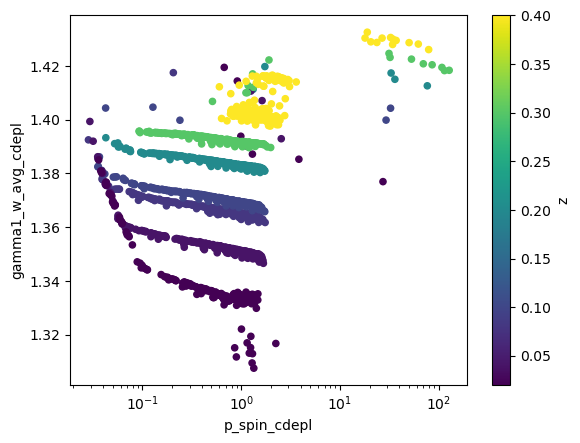

In [67]:
fig, ax = plt.subplots()
suc_che_df.plot.scatter(y='gamma1_w_avg_cdepl', x='p_spin_cdepl', c='z', ax=ax)
ax.set_xscale('log')

In [35]:
odepl_df = suc_che_df[suc_che_df.is_O_depleted].copy()

In [39]:
suc_che_df.z.unique()

array([0.08, 0.2 , 0.1 , 0.04, 0.02, 0.3 , 0.4 ])

In [37]:
odepl_df[odepl_df.z == 0.1]

,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_cdepl,m_odepl,m_f,m_c_zams,...,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_O_depleted,is_crash,z
2695,0.1000,80.0,79.291928,55.289169,43.487064,33.47627,33.417166,33.416511,33.416511,59.33493,...,True,False,False,False,True,True,True,True,False,0.1


Text(20, 1.3363333333333332, '$\\Gamma_1$ = 4/3')

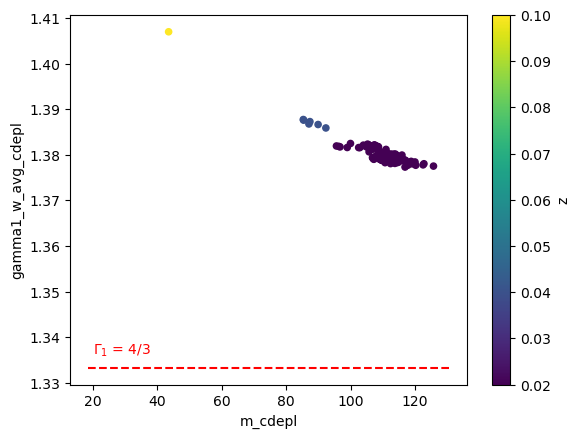

In [ ]:
fig, ax = plt.subplots()
suc_che_df[(suc_che_df.is_O_depleted)].plot.scatter(x='m_cdepl', y='gamma1_w_avg_cdepl', c='z', colormap='viridis', ax=ax)
ax.hlines(4/3, xmin=suc_che_df['m_cdepl'].min(), xmax=suc_che_df['m_cdepl'].max(), colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

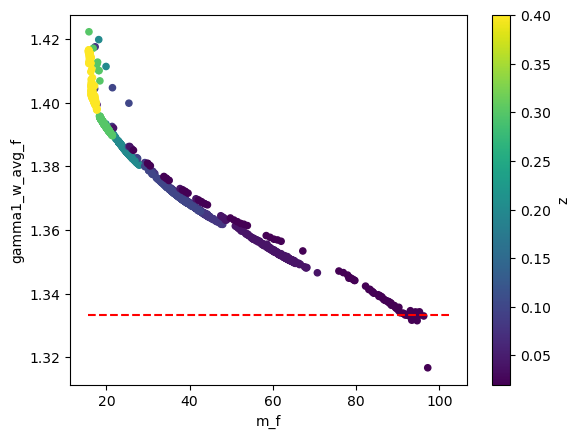

In [ ]:
fig, ax = plt.subplots()
suc_che_df[(suc_che_df.is_C_depleted) & (~suc_che_df.is_O_depleted)].plot.scatter(x='m_f', y='gamma1_w_avg_f', c='z', colormap='viridis', ax=ax)
ax.hlines(4/3, xmin=suc_che_df['m_f'].min(), xmax=suc_che_df['m_f'].max(), colors='r', linestyles='dashed')

<Axes: xlabel='m_f', ylabel='z'>

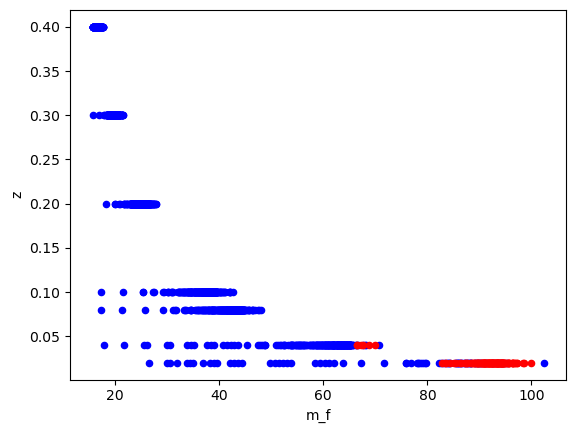

In [61]:
fig, ax = plt.subplots()
suc_che_df[suc_che_df.gamma1_w_avg_f > 4/3].plot.scatter(x='m_f', y='z', color='b', ax=ax)
suc_che_df[suc_che_df.gamma1_w_avg_f <= 4/3].plot.scatter(x='m_f', y='z', color='r', ax=ax)

In [28]:
core_props_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6720 entries, 0 to 6719
Data columns (total 77 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   z_key                 6720 non-null   object 
 1   m_zams                6720 non-null   float64
 2   m_wr0                 1839 non-null   float64
 3   m_wr1                 1839 non-null   float64
 4   m_tams                1839 non-null   float64
 5   m_tahems              1839 non-null   float64
 6   m_f                   1839 non-null   float64
 7   m_c_zams              1839 non-null   float64
 8   m_c_wr0               1839 non-null   float64
 9   m_c_wr1               1839 non-null   float64
 10  m_c_tams              1839 non-null   float64
 11  m_c_tahems            1839 non-null   float64
 12  m_c_f                 1839 non-null   float64
 13  inertia_zams          1839 non-null   float64
 14  inertia_wr0           1839 non-null   float64
 15  inertia_wr1           1839

In [6]:
def pressure_avg_gamma1(profile):
    """Compute the pressure-averaged adiabatic index gamma1."""
    dm =  profile.dm
    P = 10.**profile.logP
    rho = 10.**profile.logRho
    gamma1 = profile.gamma1

    avg_gamma1 = np.sum(gamma1 * P / rho * dm) / np.sum(P / rho * dm)
    return avg_gamma1

def pi_check(profile, tolerance=0.05):
    """Check if the model is pair-instability affected."""
    avg_gamma1 = pressure_avg_gamma1(profile)
    cnt_gamma1 = profile.gamma1[-1]
    if avg_gamma1 < 4/3 + tolerance:
        if cnt_gamma1 <= 4/3:
            return 'pisn'
        else:
            return 'ppisn'
    else:
        return 'stable'

In [7]:
core_props_df.columns

Index(['z_key', 'm_zams', 'm_wr0', 'm_wr1', 'm_tams', 'm_tahems', 'm_f',
       'm_c_zams', 'm_c_wr0', 'm_c_wr1', 'm_c_tams', 'm_c_tahems', 'm_c_f',
       'inertia_zams', 'inertia_wr0', 'inertia_wr1', 'inertia_tams',
       'inertia_tahems', 'inertia_f', 'p_spin_zams', 'p_spin_wr0',
       'p_spin_wr1', 'p_spin_tams', 'p_spin_tahems', 'p_spin_f', 'r_zams',
       'r_wr0', 'r_wr1', 'r_tams', 'r_tahems', 'r_f', 'r_c_zams', 'r_c_wr0',
       'r_c_wr1', 'r_c_tams', 'r_c_tahems', 'r_c_f', 'log_rho_c_zams',
       'log_rho_c_wr0', 'log_rho_c_wr1', 'log_rho_c_tams', 'log_rho_c_tahems',
       'log_rho_c_f', 'log_j_zams', 'log_j_wr0', 'log_j_wr1', 'log_j_tams',
       'log_j_tahems', 'log_j_f', 'p_orb_zams', 'p_orb_wr0', 'p_orb_wr1',
       'p_orb_tams', 'p_orb_tahems', 'p_orb_f', 'log_t_d', 'is_che',
       'is_crit_at_zams', 'is_merger_at_zams', 'is_l2of_at_zams',
       'is_He_depleted', 'is_half_C_depleted', 'is_C_depleted', 'is_crash'],
      dtype='object')

In [18]:
test_profile = mr.MesaData(str(all_model_dicts['0.1']['90.0']['1.20']/ 'LOGS'/ 'C_depl.data' ))

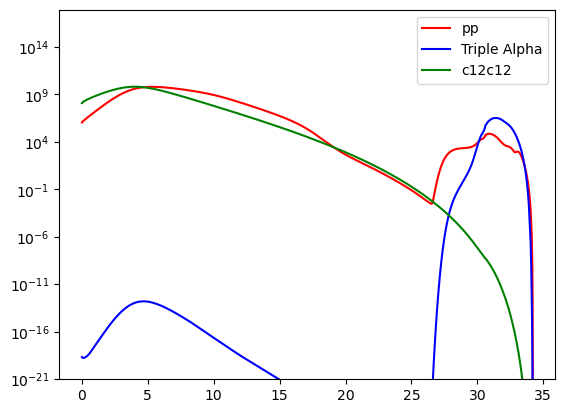

In [25]:
plt.plot(test_profile.mass, test_profile.cno, 'r', label='pp')
plt.plot(test_profile.mass, test_profile.tri_alpha, 'b', label='Triple Alpha')
plt.plot(test_profile.mass, test_profile.c12_c12, 'g', label='c12c12')
plt.yscale('log')
plt.ylim(1e-21)
plt.legend()

In [ ]:
import pandas as pd
core_props_df = pd.read_hdf(DATA_DIR/'00_fiducial_core_props_df.h5')

In [15]:
test_profile.bulk_names

('zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'dm',
 'logdq',
 'log_g',
 'radius',
 'velocity',
 'scale_height',
 'pressure_scale_height',
 'dq',
 'energy',
 'entropy',
 'prad',
 'pgas',
 'pgas_div_ptotal',
 'eta',
 'mu',
 'grada',
 'dE_dRho',
 'cp',
 'gamma1',
 'csound',
 'v_div_cs',
 'net_nuclear_energy',
 'net_energy',
 'eps_nuc',
 'non_nuc_neu',
 'pp',
 'cno',
 'tri_alpha',
 'c_alpha',
 'n_alpha',
 'o_alpha',
 'ne_alpha',
 'na_alpha',
 'mg_alpha',
 'si_alpha',
 's_alpha',
 'ar_alpha',
 'ca_alpha',
 'ti_alpha',
 'cr_alpha',
 'fe_co_ni',
 'c12_c12',
 'c12_o16',
 'o16_o16',
 'pnhe4',
 'photo',
 'ni56_co56',
 'co56_fe56',
 'other',
 'abar',
 'zbar',
 'z2bar',
 'ye',
 'neut',
 'h1',
 'h2',
 'he3',
 'he4',
 'li7',
 'be7',
 'be9',
 'be10',
 'b8',
 'c12',
 'c13',
 'n13',
 'n14',
 'n15',
 'o14',
 'o15',
 'o16',
 'o17',
 'o18',
 'f17',
 'f18',
 'f19',
 'ne18',
 'ne19',
 'ne20',
 'ne21',
 'ne22',
 'na21',
 'na2

In [5]:
import os
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import traceback

PI_TOL = 0.05
MAX_WORKERS = min(92, (os.cpu_count() or 1) * 2)
pi_dict = {}

def compute_pi_task_thread(args):
    """Top-level function for threads: takes a single tuple arg and returns a fixed tuple."""
    z_key, m_key, p_key, test_folder = args
    core_props = core_props_df[(core_props_df.)]
    try:
        # import inside function if necessary to avoid surprising top-level state
        profiles = mr.MesaLogDir(str(test_folder / 'LOGS'))
        last_profile = profiles.profile_data()
        pi_value = pi_check(last_profile, tolerance=PI_TOL)
        return (z_key, m_key, p_key, pi_value, None)
    except Exception:
        return (z_key, m_key, p_key, None, traceback.format_exc())

# Build the tasks list correctly (replace ... placeholder)
tasks = [
    (z_key, m_key, p_key, test_folder)
    for z_key, z_dict in all_model_dicts.items()
    for m_key, m_dict in z_dict.items()
    for p_key, test_folder in m_dict.items()
]

# Sanity-check: make sure tasks is a list of 4-tuples
if not tasks:
    print("No tasks found: check all_model_dicts is not empty.")
else:
    # Optional quick debug to detect stray ellipsis
    for i, t in enumerate(tasks[:10]):
        if not (isinstance(t, tuple) and len(t) == 4):
            raise TypeError(f"Bad task at index {i}: {t!r}")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as exe:
    # exe.map returns an iterator of results in submission order
    results_iter = exe.map(compute_pi_task_thread, tasks)
    # Wrap with tqdm to show a progress bar (provide total)
    for z_key, m_key, p_key, pi_value, tb in tqdm(results_iter, total=len(tasks)):
        if tb:
            # log the error and continue
            print(f"Task error for {z_key}/{m_key}/{p_key}:\n{tb}")
            continue
        pi_dict.setdefault(z_key, {}).setdefault(m_key, {})[p_key] = pi_value


  6%|▋         | 436/6720 [30:23<2:38:47,  1.52s/it]   

Task error for 0.02/70.0/0.50:
Traceback (most recent call last):
  File "/tmp/ipykernel_527582/240339618.py", line 15, in compute_pi_task_thread
    profiles = mr.MesaLogDir(str(test_folder / 'LOGS'))
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1027, in __init__
    self.read_logs()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1050, in read_logs
    self.profiles = MesaProfileIndex(self.index_path)
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 773, in __init__
    self.read_index()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 795, in read_index
    self.index_data = temp_index_data[np.argsort(temp_index_data[:, 0])]
IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed



  8%|▊         | 560/6720 [36:49<10:44,  9.56it/s]  

Task error for 0.02/100.0/0.60:
Traceback (most recent call last):
  File "/tmp/ipykernel_527582/240339618.py", line 15, in compute_pi_task_thread
    profiles = mr.MesaLogDir(str(test_folder / 'LOGS'))
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1027, in __init__
    self.read_logs()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1050, in read_logs
    self.profiles = MesaProfileIndex(self.index_path)
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 773, in __init__
    self.read_index()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 795, in read_index
    self.index_data = temp_index_data[np.argsort(temp_index_data[:, 0])]
IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed



  9%|▉         | 595/6720 [36:55<18:09,  5.62it/s]

...

 94%|█████████▍| 6349/6720 [5:01:32<02:41,  2.29it/s]

Task error for 0.4/120.0/0.50:
Traceback (most recent call last):
  File "/tmp/ipykernel_527582/240339618.py", line 15, in compute_pi_task_thread
    profiles = mr.MesaLogDir(str(test_folder / 'LOGS'))
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1027, in __init__
    self.read_logs()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1050, in read_logs
    self.profiles = MesaProfileIndex(self.index_path)
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 773, in __init__
    self.read_index()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 795, in read_index
    self.index_data = temp_index_data[np.argsort(temp_index_data[:, 0])]
IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed



 95%|█████████▍| 6362/6720 [5:01:44<05:26,  1.10it/s]

Task error for 0.4/140.0/0.50:
Traceback (most recent call last):
  File "/tmp/ipykernel_527582/240339618.py", line 15, in compute_pi_task_thread
    profiles = mr.MesaLogDir(str(test_folder / 'LOGS'))
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1027, in __init__
    self.read_logs()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 1050, in read_logs
    self.profiles = MesaProfileIndex(self.index_path)
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 773, in __init__
    self.read_index()
  File "/mnt/home/ldesa/venvdir/cher/lib/python3.10/site-packages/mesa_reader/__init__.py", line 795, in read_index
    self.index_data = temp_index_data[np.argsort(temp_index_data[:, 0])]
IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed



100%|██████████| 6720/6720 [5:21:32<00:00,  2.87s/it]  


In [21]:
core_props_df

,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_f,m_c_zams,m_c_wr0,m_c_wr1,...,p_orb_f,log_t_d,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_crash
0,0.0800,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,True,True,True,True,False,False,False,False
1,0.0800,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,True,True,True,True,False,False,False,False
2,0.0800,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,True,True,True,True,False,False,False,False
3,0.0800,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,False,False,False,False,False,False,False,False
4,0.0800,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6715,0.4000,240.0,232.875396,76.658026,26.995547,17.023906,16.943730,202.297718,202.297718,57.721155,...,543.558722,16.039888,True,False,False,False,True,True,True,False
6716,0.4000,220.0,196.651650,68.192422,26.300428,16.742195,16.560101,167.467238,167.467238,46.858885,...,96.863215,14.420952,True,False,False,False,True,True,True,False
6717,0.4000,220.0,202.478298,69.411940,26.407149,16.788141,16.641926,172.879446,172.879446,48.494528,...,146.618799,14.784654,True,False,False,False,True,True,True,False
6718,0.4000,220.0,210.826633,71.289276,26.558843,16.867985,16.714995,180.570869,180.570869,50.746748,...,327.563606,15.489194,True,False,False,False,True,True,True,False


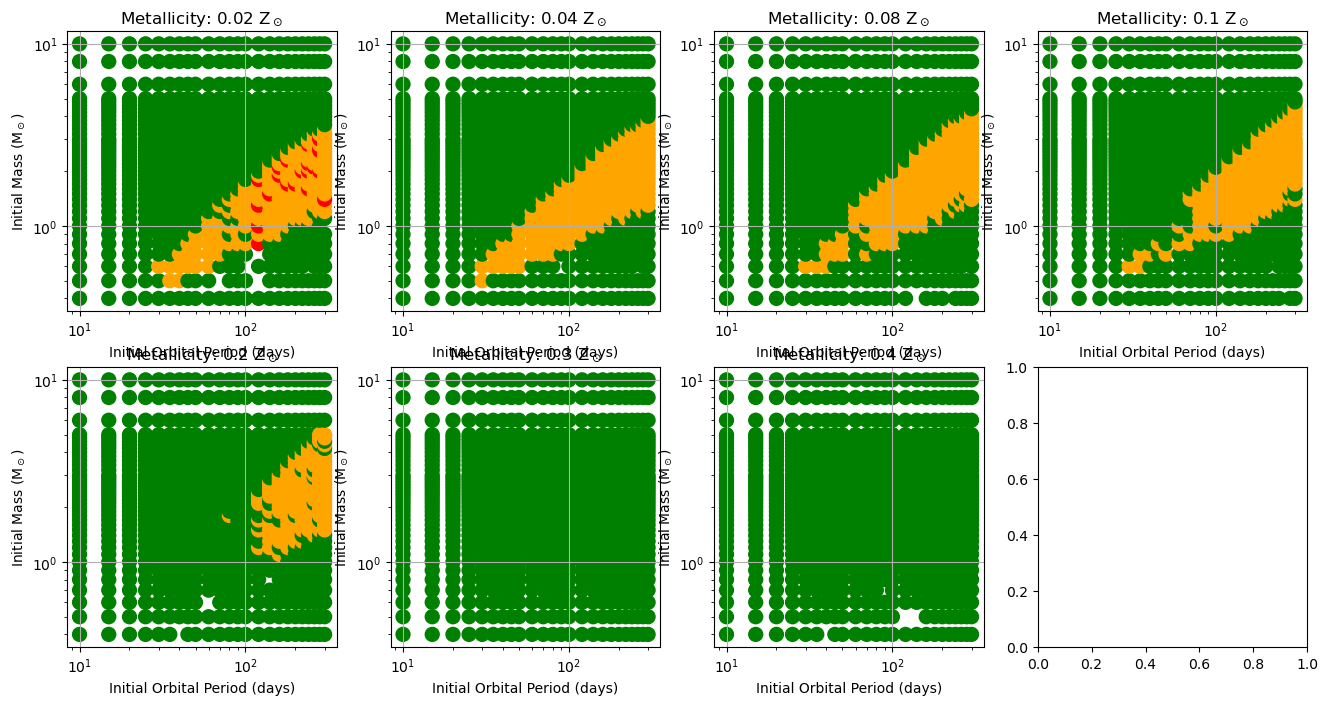

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for (z_key, z_dict), ax in zip(pi_dict.items(), axes.flatten()):
    for m_key, m_dict in z_dict.items():
        p_keys = sorted(m_dict.keys(), key=lambda x: float(x))
        p_values = [float(p) for p in p_keys]
        pi_values = [pi_dict[z_key][m_key][p] for p in p_keys]
        
        colors = {'stable': 'green', 'ppisn': 'orange', 'pisn': 'red'}
        color_values = [colors[pi] for pi in pi_values]

        ax.scatter([float(m_key)] * len(p_values), p_values, c=color_values, label=m_key, s=100)

    ax.set_title(f'Metallicity: {z_key} Z$_\\odot$')
    ax.set_xlabel('Initial Orbital Period (days)')
    ax.set_ylabel('Initial Mass (M$_\\odot$)')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(True)

In [7]:
import pickle

with open("result.pkl", "wb") as f:
    pickle.dump(pi_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
